Before diving into feature engineering and data analysis first thing is to understand the data and the context behind it, this notebook aims to understand the GeoHab 2026 data from what the files provided are about to how to extract features from it.

## What is this dataset actually about
Imagine scientists exploring the ocean floor.
They send a ship with a sonar device called a Multibeam Echosounder (MBES).
The device sends sound waves down and measures how they bounce back.
From this they get two types of information:

1. How deep the seafloor is
2. What the seafloor surface is like

That information is stored as maps. Thoes maps are stored in **TIFF** / **.tif** files

## What are thoes **.tif** files
.tif (GeoTIFF) is basically an image that also stores geographic information.

Think of it like this:

Normal image:

    pixel pixel pixel
    pixel pixel pixel
    pixel pixel pixel
GeoTIFF image:

    pixel pixel pixel
    pixel pixel pixel
    pixel pixel pixel
BUT every pixel also knows:

    this pixel = location (x,y)
So it is a map made of pixels where each pixel has a value.

## Dataset Files
1. **bathymetry.tif**

Bathymetry means depth of the ocean floor.
So each pixel stores:
Depth at that location

Example:

    Location    Depth
    (x1,y1)	     35m
    (x2,y2)	     42m
    (x3,y3)	     12m

So this file is basically a depth map of the seabed.

2. **backscatter.tif**

Backscatter tells us how strongly sound reflects back.
Different surfaces reflect sound differently.

Example:

    Surface	 Backscatter
    sand	  medium
    rock	  strong
    mud	  weak

So this file is basically a surface texture map.

## What should the model learn 
The ML model must learn interactions/patterns like:

    Depth = 30m
    Backscatter = high
    → rock
    
    Depth = 10m
    Backscatter = low
    → sand
    
    Depth = 15m
    Backscatter = medium
    → seagrass
    
So the model learns:
    
    (depth + texture) → habitat type

This is how a raster image looks like:

                x →
        y ↓
              100  101  102  103
        200   30   32   35   40
        201   28   30   33   38
        202   20   22   25   30

So:

* (x=101, y=200) → depth = 32
* (x=102, y=201) → depth = 33

## Importing data

In [8]:
import rasterio

back = rasterio.open("/kaggle/input/competitions/geohab-mlwg-competition-2026/MBES/backscatter.tif")
bath = rasterio.open("/kaggle/input/competitions/geohab-mlwg-competition-2026/MBES/bathymetry.tif")

In [9]:
bath_data = bath.read(1)   # band 1 (main data)
back_data = back.read(1)

print(bath_data.shape) #rows x columns

(4040, 4743)


In [10]:
print(bath_data[:5, :5])

[[-10000. -10000. -10000. -10000. -10000.]
 [-10000. -10000. -10000. -10000. -10000.]
 [-10000. -10000. -10000. -10000. -10000.]
 [-10000. -10000. -10000. -10000. -10000.]
 [-10000. -10000. -10000. -10000. -10000.]]


## Visualizing as Image
Here we'll be plotting heatmap more like depth map where:

**Bathymetry:**
* Dark = deep water
* Bright = shallow water

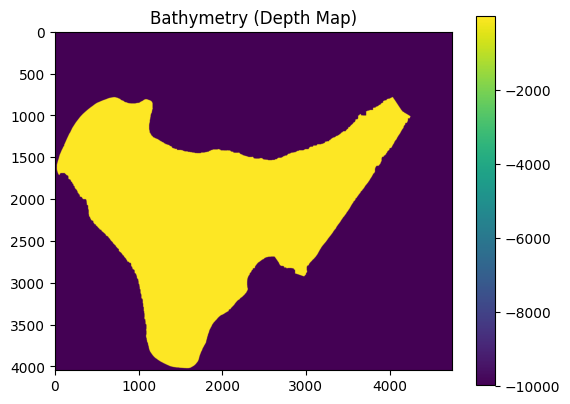

In [11]:
import matplotlib.pyplot as plt

plt.imshow(bath_data)
plt.title("Bathymetry (Depth Map)")
plt.colorbar()
plt.show()

**Backscatter:**
* Bright = strong reflection (rocky)
* Dark = weak reflection (mud/sand)

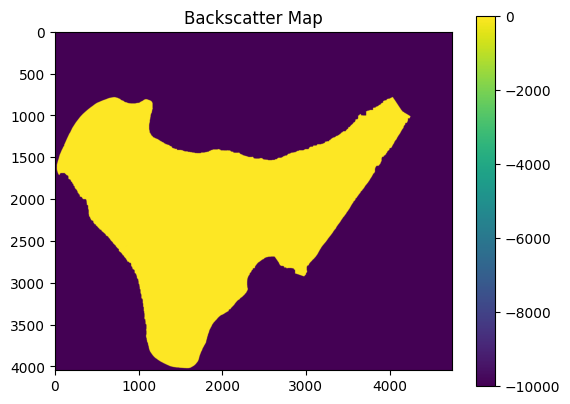

In [12]:
plt.imshow(back_data)
plt.title("Backscatter Map")
plt.colorbar()
plt.show()

##

## Plotting data points over the map:
This would give us some idea about 
* Do some classes cluster in certain regions?
* Are some classes only in shallow/deep areas?

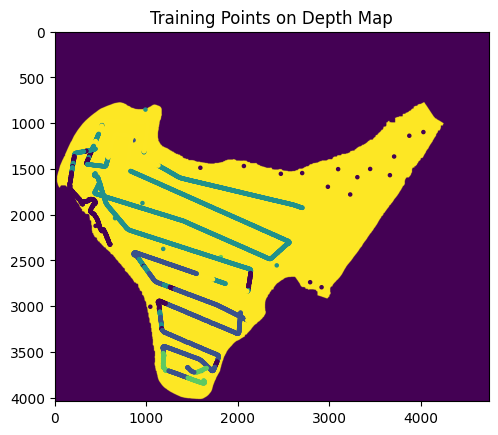

In [13]:
import matplotlib.pyplot as plt
import pandas as pd

train = pd.read_csv("/kaggle/input/competitions/geohab-mlwg-competition-2026/train.csv")

# convert all points to pixel coords
rows, cols = zip(*[bath.index(x, y) for x, y in zip(train.x, train.y)])

plt.imshow(bath_data)
plt.scatter(cols, rows, c=train['class'].astype('category').cat.codes, s=5)
plt.title("Training Points on Depth Map")
plt.show()

## Feature Extraction

In [14]:
def get_features(x, y):
    row, col = bath.index(x, y)
    return bath_data[row, col], back_data[row, col]

train[['depth', 'scatter']] = train.apply(
    lambda r: pd.Series(get_features(r['x'], r['y'])),
    axis=1
)

In [15]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6256 entries, 0 to 6255
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   class    6256 non-null   object 
 1   x        6256 non-null   float64
 2   y        6256 non-null   float64
 3   depth    6256 non-null   float32
 4   scatter  6256 non-null   float32
dtypes: float32(2), float64(2), object(1)
memory usage: 195.6+ KB


In [16]:
train[['depth','scatter']].describe()

,depth,scatter
count,6256.000000,6256.000000
mean,-8.568404,-23.904961
std,2.939247,4.177290
min,-20.247799,-39.139683
25%,-10.757194,-26.859035
50%,-8.688892,-24.019592
75%,-6.291407,-21.499985
max,-1.119716,-12.049013


## Distribution analysis:

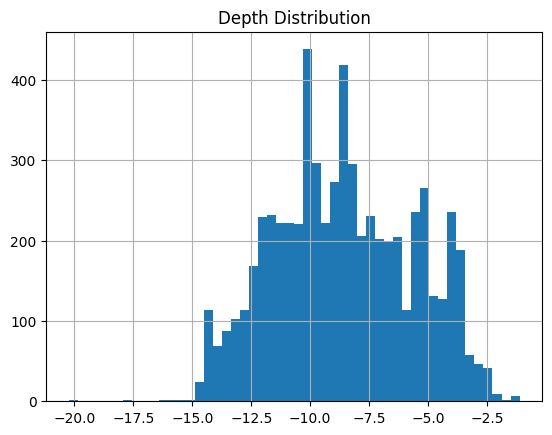

In [17]:
train['depth'].hist(bins=50)
plt.title("Depth Distribution")
plt.show()

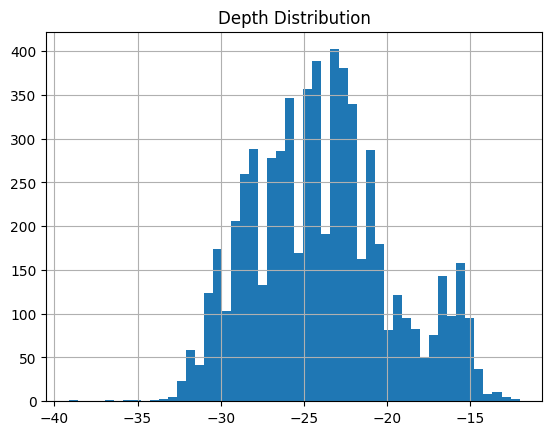

In [18]:
train['scatter'].hist(bins=50)
plt.title("Depth Distribution")
plt.show()

## Relationshipwith class
* Do classes have different depth ranges?
* Does scatter separate classes?

If yes → model will perform well

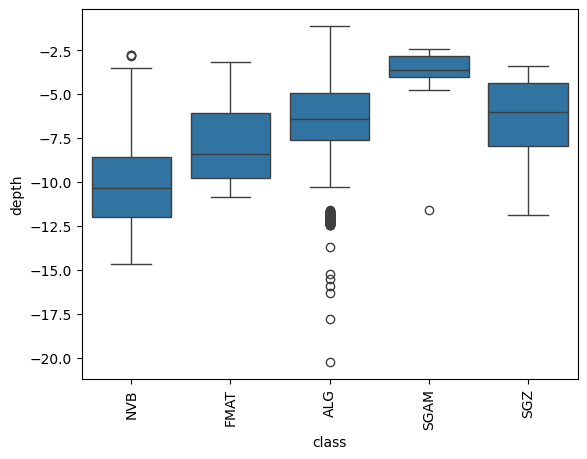

In [19]:
import seaborn as sns

sns.boxplot(x='class', y='depth', data=train)
plt.xticks(rotation=90)
plt.show()

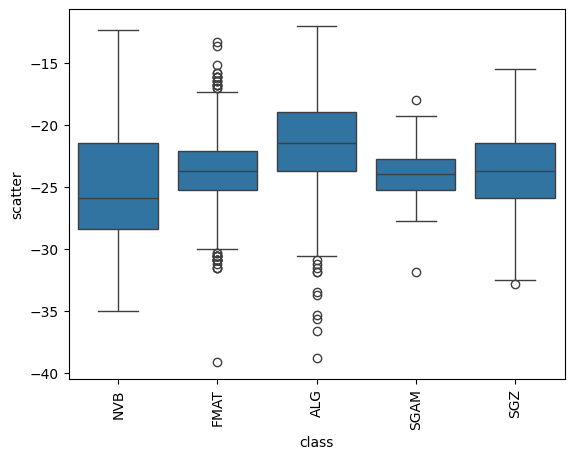

In [20]:
sns.boxplot(x='class', y='scatter', data=train)
plt.xticks(rotation=90)
plt.show()

## Scatter plot:
Answers if the classes are seperable or not, also if they form any clusters

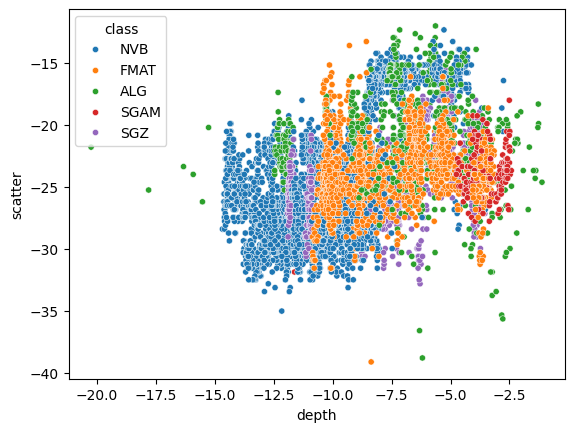

In [21]:
sns.scatterplot(
    x='depth',
    y='scatter',
    hue='class',
    data=train,
    s=20
)
plt.show()

## Class imbalance check:

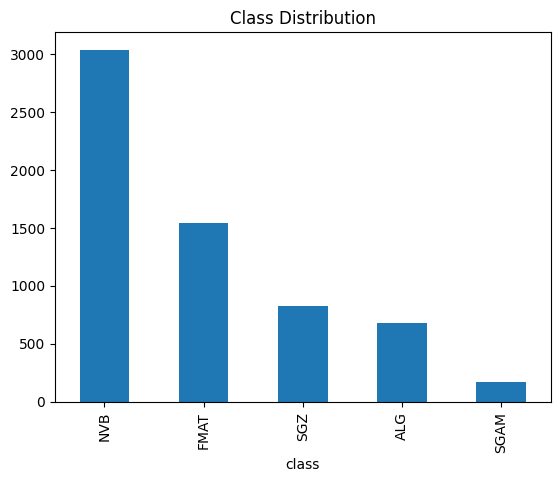

In [22]:
train['class'].value_counts().plot(kind='bar')
plt.title("Class Distribution")
plt.show()

It is clearly visible that theres a classs imbalance so we will hae to move forward with caution

## Over all stats

In [23]:
print("Depth stats:", bath_data.min(), bath_data.max())
print("Scatter stats:", back_data.min(), back_data.max())

Depth stats: -10000.0 -0.08377636
Scatter stats: -10000.0 1.8100528


In [24]:
#cehcking missing values
import numpy as np

print(np.isnan(bath_data).sum())
print(np.isnan(back_data).sum())

0
0


## Spatial features

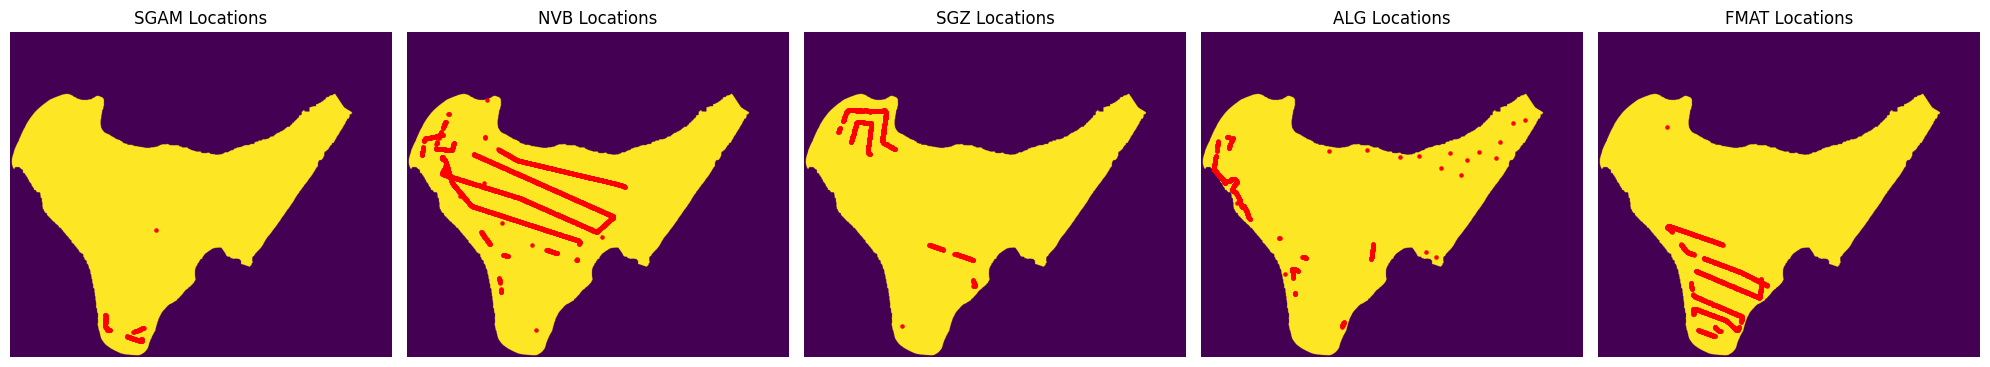

In [27]:
import matplotlib.pyplot as plt

classes = ['SGAM', 'NVB', 'SGZ', 'ALG', 'FMAT']

fig, axes = plt.subplots(1, len(classes), figsize=(20, 5))  # 1 row, 5 columns

for idx, i in enumerate(classes):
    ax = axes[idx]
    
    mask = train['class'] == i
    
    ax.imshow(bath_data)
    ax.scatter(
        [c for c, m in zip(cols, mask) if m],
        [r for r, m in zip(rows, mask) if m],
        color='red',
        s=5
    )
    
    ax.set_title(f"{i} Locations")
    ax.axis('off')  # optional: removes axis ticks

plt.tight_layout()
plt.show()